<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [261]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
import plotly.express as px

# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла. 

In [262]:
df = pd.read_csv('data/dst-3.0_16_1_hh_database.csv',  delimiter=';')

2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [263]:
display(df.head(2))
display(df.tail(2))

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано


,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
44742,"Мужчина , 24 года , родился 6 октября 1994",20000 руб.,Контент-менеджер,"Тамбов , не готов к переезду , не готов к кома...","частичная занятость, полная занятость",удаленная работа,Опыт работы 3 года 10 месяцев Контент-менедже...,IQ-Maxima,Менеджер проектов,Высшее образование 2015 Тамбовский государств...,26.04.2019 14:25,Имеется собственный автомобиль
44743,"Мужчина , 38 лет , родился 25 апреля 1980",120000 руб.,Руководитель проекта,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 15 лет 10 месяцев Руководитель пр...,ПАО ГК ТНС энерго,Руководитель отдела технической поддержки,Высшее образование 1997 Южно-Российский госуд...,05.07.2018 20:15,Не указано


3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

In [264]:
# 3
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Пол, возраст                     44744 non-null  str  
 1   ЗП                               44744 non-null  str  
 2   Ищет работу на должность:        44744 non-null  str  
 3   Город, переезд, командировки     44744 non-null  str  
 4   Занятость                        44744 non-null  str  
 5   График                           44744 non-null  str  
 6   Опыт работы                      44576 non-null  str  
 7   Последнее/нынешнее место работы  44743 non-null  str  
 8   Последняя/нынешняя должность     44742 non-null  str  
 9   Образование и ВУЗ                44744 non-null  str  
 10  Обновление резюме                44744 non-null  str  
 11  Авто                             44744 non-null  str  
dtypes: str(12)
memory usage: 437.5 MB
None


4. Обратите внимание на информацию о числе непустых значений. \
Выберите все признаки, в которых есть пропуски в данных:

In [265]:
print(f'{df.columns[df.isnull().any()].tolist()}')

['Опыт работы', 'Последнее/нынешнее место работы', 'Последняя/нынешняя должность']


5. Выведите основную статистическую информацию о столбцах.


In [266]:
df.describe(include='all')

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 2014 Московский технически...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [267]:
def educ(val):
    m_ed = val.split(' ')
    ed = (m_ed[0]+m_ed[1])
    return 'высшее' if 'Высшее' in ed else 'неоконченное высшее' if 'Неоконченное' in ed else 'среднее специальное' if 'специальное' in ed else 'среднее'

df_c = df.copy()
df_c['Образование'] = df['Образование и ВУЗ'].apply(educ)
print(f'Статистика Образование:\n {df_c['Образование'].value_counts()}')
print(f'уникальные уровни Образования: {df_c['Образование'].unique()}')
df_c.drop(['Образование и ВУЗ'],axis=1, inplace=True)
print(f'Итоговые столбцы: {df_c.columns}')

Статистика Образование:
 Образование
высшее                 33863
среднее специальное     5765
неоконченное высшее     4557
среднее                  559
Name: count, dtype: int64
уникальные уровни Образования: <ArrowStringArray>
['неоконченное высшее', 'высшее', 'среднее специальное', 'среднее']
Length: 4, dtype: str
Итоговые столбцы: Index(['Пол, возраст', 'ЗП', 'Ищет работу на должность:',
       'Город, переезд, командировки', 'Занятость', 'График', 'Опыт работы',
       'Последнее/нынешнее место работы', 'Последняя/нынешняя должность',
       'Обновление резюме', 'Авто', 'Образование'],
      dtype='str')


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979 
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина. 
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '. 
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [268]:
def gend_age(val):
    m_g_a = val.split(' , ')
    gen = 'М' if m_g_a[0] == 'Мужчина' else 'Ж'
    ag = pd.to_numeric(m_g_a[1].split(" ")[1]) #делю возраст на кол-во и слово
    return pd.Series([ gen, ag])

df_c[['Пол', 'Возраст']] = df['Пол, возраст'].apply(gend_age)
print(f'Уникальные гендеры: {df_c['Пол'].unique()}')
cnt_rec = df_c['Пол'].shape[0]
cnt_w = df_c[df_c['Пол'] == 'Ж'].shape[0]
print(f'Всего гендеров: {cnt_rec} из них "Ж" = {cnt_w}, что составляет: {round(cnt_w/(cnt_rec/100), 2)}%')

print(f'Уникальные возрасты: {df_c['Возраст'].unique()}')
print(f'Средний возраст: {round(df_c['Возраст'].mean(), 1)}')
df_c.drop(['Пол, возраст'],axis=1, inplace=True)

Уникальные гендеры: <ArrowStringArray>
['М', 'Ж']
Length: 2, dtype: str
Всего гендеров: 44744 из них "Ж" = 8533, что составляет: 19.07%
Уникальные возрасты: [ 39  60  36  38  26  29  46  34  35  59  27  21  31  37  30  33  42  32
  23  28  25  24  43  53  49  44  48  54  22  20  40  62  72  45  41  61
  50  58  57  52  56  18  19  51  16  47  71  63  55  64  68  17  73  66
  65  77  67  69  76  70  14  15 100]
Средний возраст: 32.2


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**. 

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [269]:
def m_wrk(val):
    if type(val) != str:
        return np.nan
    if val == 'Не указано':
        return np.nan
    pref = 'Опыт работы'
    ym = val[len(pref): len(pref) + 20].strip().split(' ')
    y = 0
    m = 0
    i = 0
    for fy in ym:
        if 'ГОД' in fy.upper() or 'ЛЕТ' in fy.upper():
            if i == 0:
                y = 0
            else:
                y = int(ym[i-1] or 0)
            break
        i += 1
    i = 0
    for fm in ym:
        if 'МЕС' in fm.upper():
            if i == 0:
                m = 0
            else:
                m = int(ym[i-1] or 0)
            break
        i += 1
    return y*12 + m

df_c['Опыт работы (месяц)'] = df_c[ 'Опыт работы'].apply(m_wrk);
print(df_c['Опыт работы (месяц)'].describe())
print(f'медианный опыт работы (в месяцах): {df_c['Опыт работы (месяц)'].median()}')
df_c.drop(['Опыт работы'],axis=1, inplace=True)

count    44574.000000
mean       114.418944
std         79.047861
min          1.000000
25%         57.000000
50%        100.000000
75%        154.000000
max       1188.000000
Name: Опыт работы (месяц), dtype: float64
медианный опыт работы (в месяцах): 100.0


4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , … 
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [270]:
def tf_m_o(templ, c_m_o):
# templ - шаблон поиска ГОТОВНОСТИ в c_m_o. Возвращает True если Готов
    i = 0
    move = False
    for col in c_m_o:
        if templ in col.upper():
            move = False if 'НЕ ГОТОВ' in c_m_o[i].upper() else True
            break
        i += 1
    return move

def place(val):
    million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь','Воронеж','Волгоград']
    c_m_o = val.strip().split(' , ')
    city = c_m_o[0] if c_m_o[0] in ['Москва', 'Санкт-Петербург'] else c_m_o[0] if c_m_o[0] in million_cities else 'другие'
    # ловим переезд
    move = tf_m_o('ПЕРЕЕ', c_m_o)
    # ловим командировки
    ov = tf_m_o('КОМАНДИРОВК', c_m_o)
    return pd.Series([city, move, ov])

df_c[['Город', 'Готовность к переезду', 'Готовность к командировкам']] = df_c['Город, переезд, командировки'].apply(place)
cnt_all = df_c.shape[0]
cnt_sp = df_c[df_c['Город'] == 'Санкт-Петербург']['Город'].count()
print(f'% процентов соискателей живут в Санкт-Петербурге: {cnt_all} {cnt_sp} {round(cnt_sp/(cnt_all/100), 0)}')
cnt_m = df_c[( df_c['Готовность к переезду'] == True) & (df_c['Готовность к командировкам']== True)].shape[0]
print(f'% соискателей готовы одновременно и к переездам, и к командировкам: (всего:{cnt_all} готовых:{cnt_m}) {round(cnt_m/(cnt_all/100), 0)}')
df_c.drop(['Город, переезд, командировки'],axis=1, inplace=True)


% процентов соискателей живут в Санкт-Петербурге: 44744 4937 11.0
% соискателей готовы одновременно и к переездам, и к командировкам: (всего:44744 готовых:14258) 32.0


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>\
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [271]:
def type_wrk( val):
    type_z = val
    full = False
    ch = False
    proj = False
    stag = False
    volo = False
    full = True if 'полная занятость' in type_z else False
    ch = True if 'частичная занятость' in type_z else False
    proj = True if 'проектная работа' in type_z else False
    stag = True if 'стажировка' in type_z else False
    volo = True if 'волонтерство' in type_z else False
    return pd.Series([ full, ch, proj, stag, volo])
def type_graf( val):
    type_z = val
    full = False
    ch = False
    proj = False
    stag = False
    volo = False
    full = True if 'полный день' in type_z else False
    ch = True if 'сменный график' in type_z else False
    proj = True if 'гибкий график' in type_z else False
    stag = True if 'удаленная работа' in type_z else False
    volo = True if 'вахтовый метод' in type_z else False
    return pd.Series([ full, ch, proj, stag, volo])

df_c[['полная занятость', 'частичная занятость', 'проектная работа', 'стажировка', 'волонтерство']] = df_c['Занятость'].apply(type_wrk);
df_c[['полный день', 'сменный график', 'гибкий график', 'удаленная работа', 'вахтовый метод']] = df_c['График'].apply(type_graf);

print(f'проектная работа И волонтерство: {df_c[df_c['проектная работа'] & df_c['волонтерство']].shape[0]}')
print(f'вахтовый метод И гибкий график: {df_c[(df_c['вахтовый метод'] == True) & (df_c['гибкий график']==True)].shape[0]}')
df_c.drop(['Занятость', 'График'],axis=1, inplace=True)

проектная работа И волонтерство: 436
вахтовый метод И гибкий график: 2311


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**. 
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата, 
* "proportion" - пропорция, 
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования: 
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [272]:
def zp_cur(val):
    zp_c = val.split(' ')
    return pd.Series([float(zp_c[0]), zp_c[1].replace('.', '')])
def mk_key_dt_cur(val):
    ret = f'{val.iloc[1]}_{val.iloc[0]}'
    return  ret
def mk_key_dt_iso(val):
    dic_cur = {'грн': 'UAH', 'USD':'USD', 'EUR':'EUR', 'руб':'RUR', 'белруб': 'BYN', 'KZT':'KZT', 'AZN':'AZN', 'сум':'UZS', 'KGS':'KGS'}
    ret = f'{val.iloc[1]}_{dic_cur[val.iloc[0]]}'
    return  ret

df_cur = pd.read_csv('data/ExchangeRates.csv',  delimiter=',')
df_cur['date_'] = pd.to_datetime(df_cur['date'], dayfirst = True).dt.date # !!! удалить в конце
df_c['Обновление резюме'] = pd.to_datetime(df_c['Обновление резюме'], dayfirst = True).dt.date
df_c[['val ЗП', 'cur ЗП']] = df_c['ЗП'].apply(zp_cur) # делю ЗП на сумму и валюту !!! удалить в конце

df_cur['key_dt_cur'] = df_cur[['currency', 'date_']].apply(mk_key_dt_cur, axis=1) #key валюта_дата
df_c['key_dt_cur'] = df_c[['cur ЗП', 'Обновление резюме' ]].apply(mk_key_dt_iso, axis=1) #key валюта_дата !!! удалить в конце
df_c = df_c.merge(df_cur, how='left')
df_c = df_c.fillna({'close': 1, 'proportion': 1})
df_c['ЗП (руб)'] = df_c[['val ЗП', 'close', 'proportion']].apply(lambda x: (x['val ЗП'] / x['proportion']) * x['close'], axis=1)
print(f'ЗП (руб.) median = {df_c['ЗП (руб)'].median()}')
df_c.drop(['date_', 'vol', 'time', 'date','per', 'currency', 'key_dt_cur', 'cur ЗП','ЗП', 'val ЗП', 'close', 'proportion' ],axis=1, inplace=True) #
df_c.info()

ЗП (руб.) median = 59019.0
<class 'pandas.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-null  str    
 1   Последнее/нынешнее место работы  44743 non-null  str    
 2   Последняя/нынешняя должность     44742 non-null  str    
 3   Обновление резюме                44744 non-null  object 
 4   Авто                             44744 non-null  str    
 5   Образование                      44744 non-null  str    
 6   Пол                              44744 non-null  str    
 7   Возраст                          44744 non-null  int64  
 8   Опыт работы (месяц)              44574 non-null  float64
 9   Город                            44744 non-null  str    
 10  Готовность к переезду            44744 non-null  bool   
 11  Готовность к командировкам       44744 non-null  bool   
 12  по

## Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

#### Анализ Возраста

In [273]:
print(f'модальное значение возраста соискателей: {df_c['Возраст'].mode().iloc[0]}')
print(f'статистика по возрасту: {df_c['Возраст'].describe()}')
print(f'''Отклонения:\n
            {df_c[
                  (df_c["Возраст"] < df_c["Возраст"].describe()["25%"])
                    |
                  (df_c["Возраст"] > df_c["Возраст"].describe()["75%"])
                ]["Возраст"].value_counts().sort_index()}
        ''')

модальное значение возраста соискателей: 30
статистика по возрасту: count    44744.000000
mean        32.196741
std          7.929800
min         14.000000
25%         27.000000
50%         31.000000
75%         36.000000
max        100.000000
Name: Возраст, dtype: float64
Отклонения:

            Возраст
14        1
15        2
16        4
17       14
18       61
19      173
20      405
21      754
22     1284
23     1582
24     2074
25     2212
26     2372
37     1276
38     1110
39      999
40      877
41      721
42      648
43      623
44      566
45      449
46      461
47      383
48      353
49      286
50      240
51      217
52      186
53      169
54      186
55      137
56      120
57      131
58       86
59       72
60       59
61       38
62       22
63       29
64       17
65       20
66       11
67        9
68        4
69        4
70        3
71        4
72        3
73        4
76        1
77        1
100       1
Name: count, dtype: int64
        


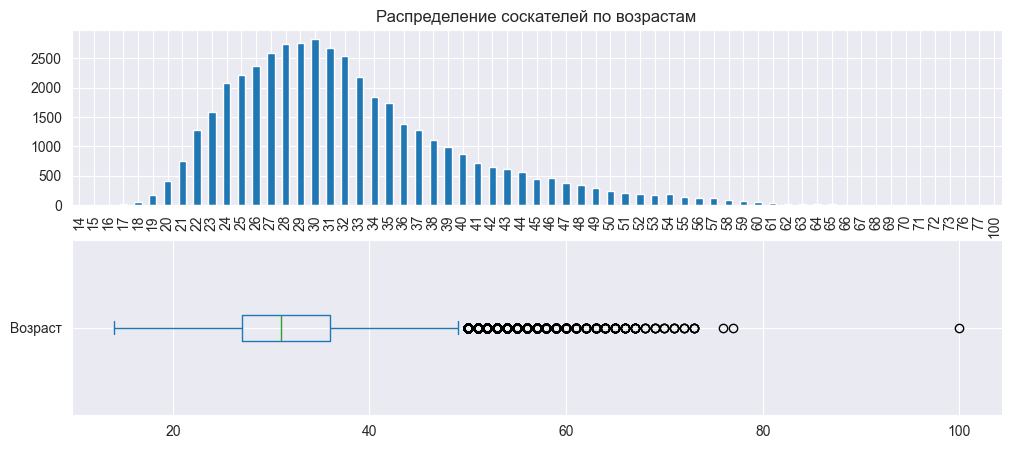

In [274]:
gr_y = df_c['Возраст'].value_counts().sort_index()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))
gr_y.plot(title= 'Распределение соскателей по возрастам', ax=ax1, kind='bar', grid=True );
gr_y = df_c['Возраст']
gr_y.plot(ax=ax2, kind='box', vert=False, grid=True, x='Возраст' );

Аномалии для возраста соискателя:
- от **14 лет** школьник хочет подработать
- старше **60 лет** до **70 лет**, пожалуй, не совсем аномалия, а вот старше **70 лет**, я бы отнес к аномалии.\
****Опять же, данные от HH, если брать данные Биржи труда, у которой контингент другой, показатели будут другими****

### Анализ Опыт работы (месяц)

In [275]:
print(f'модальное значение Опыт работы (месяц): {df_c['Опыт работы (месяц)'].mode().iloc[0]}')
print(f'статистика по Опыт работы (месяц): {df_c['Опыт работы (месяц)'].describe()}')
print(f'''Отклонения:\n
            {df_c[
                  (df_c["Опыт работы (месяц)"] < df_c["Опыт работы (месяц)"].describe()["25%"])
                    |
                  (df_c["Опыт работы (месяц)"] > df_c["Опыт работы (месяц)"].describe()["75%"])
                ]["Опыт работы (месяц)"].value_counts().sort_index()}
        ''')

модальное значение Опыт работы (месяц): 81.0
статистика по Опыт работы (месяц): count    44574.000000
mean       114.418944
std         79.047861
min          1.000000
25%         57.000000
50%        100.000000
75%        154.000000
max       1188.000000
Name: Опыт работы (месяц), dtype: float64
Отклонения:

            Опыт работы (месяц)
1.0        21
2.0        73
3.0       111
4.0       135
5.0       141
         ... 
586.0       1
622.0       1
653.0       1
663.0       1
1188.0      1
Name: count, Length: 419, dtype: int64
        


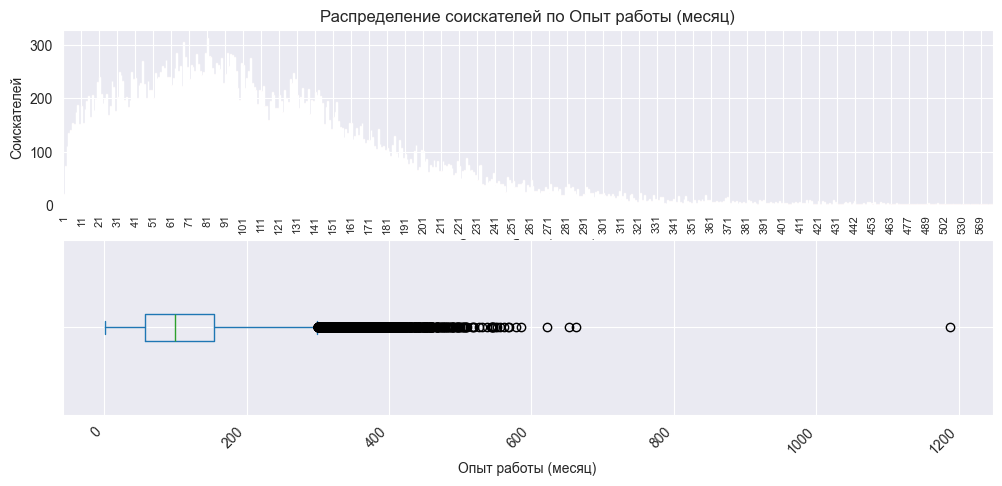

In [276]:
gr_y = df_c.groupby('Опыт работы (месяц)')['Опыт работы (месяц)'].value_counts().sort_index()
gr_y.index = gr_y.index.astype(int)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))
gr_y.plot(title= 'Распределение соискателей по Опыт работы (месяц)', ax=ax1, color='red',
            x='Опыт работы (месяц)', kind='bar', grid=True, ylabel='Соискателей' )
plt.xticks(rotation=45, ha='right')
step = 10
ticks = ax1.get_xticks()[::step]
labels = ax1.get_xticklabels()[::step]
ax1.set_xticks(ticks)
ax1.set_xticklabels(labels, rotation=90)
ax1.tick_params(axis='x', labelsize=8)

gr_y = df_c['Опыт работы (месяц)']
gr_y.plot(ax=ax2, kind='box', vert=False, grid=True);
ax2.set_yticklabels([])
ax2.set_xlabel('Опыт работы (месяц)')
plt.show()

### ЗП (руб)

In [277]:
print(f'модальное значение ЗП (руб): {df_c['ЗП (руб)'].mode().iloc[0]}')
with pd.option_context('display.float_format', '{:.0f}'.format):
    print(f'статистика по ЗП (руб): {df_c['ЗП (руб)'].describe()}')
    print(f'''Отклонения:\n
                {df_c[
                      (df_c["ЗП (руб)"] < df_c["ЗП (руб)"].describe()["25%"])
                        |
                      (df_c["ЗП (руб)"] > df_c["ЗП (руб)"].describe()["75%"])
                    ]["ЗП (руб)"].value_counts().sort_index()}
            ''')

модальное значение ЗП (руб): 50000.0
статистика по ЗП (руб): count      44744
mean       76534
std       135932
min            1
25%        37082
50%        59019
75%        95000
max     24304876
Name: ЗП (руб), dtype: float64
Отклонения:

                ЗП (руб)
1           12
18           1
25           1
27           1
30           1
            ..
1750000      1
2500000      1
3000000      1
7675224      1
24304876     1
Name: count, Length: 743, dtype: int64
            


In [278]:
df_c['ЗП (тыс. руб)'] = round(df_c['ЗП (руб)'] / 1000).astype(int)
df_y = df_c['ЗП (тыс. руб)'].value_counts().sort_index()
print(f'Максимальные ЗП в тыс.руб.:{df_y.tail(7)}')
fig = px.histogram(
    df_y,
    x=df_y.index,
    title='Гистограмма распределения заработной платы',
    labels={'ЗП (тыс. руб)': 'Зарплата (тыс. руб)', 'count': 'Частота'},
    nbins=1000,
    opacity=0.8,
    color_discrete_sequence=['#1f77b4']
)
fig.update_layout(
    showlegend=False,
    xaxis_title='Зарплата (тыс. руб)',
    yaxis_title='Количество сотрудников',
    bargap=0.05
)
fig.show()
fig = px.box(
    df_y,
    x=df_y.index,
    title='Распределение зарплат',
    labels={'ЗП (тыс. руб)': 'Зарплата, тыс. руб'}
)
fig.show()


Максимальные ЗП в тыс.руб.:ЗП (тыс. руб)
924      1
1000     1
1750     1
2500     1
3000     1
7675     1
24305    1
Name: count, dtype: int64


Аномальной можно считать ЗП до 20 тыс.руб и свыше 3 млн.руб

#### зависимость медианной желаемой заработной платы («ЗП (руб)») от уровня образования («Образование») где желаемая заработная плата меньше 1 миллиона рублей

In [279]:
df_y = df_c[df_c['ЗП (руб)'] < 1000000].groupby('Образование')['ЗП (руб)'].median().reset_index()
fig = px.bar(
    df_y,
    x='Образование',
    y='ЗП (руб)',
    title='Зависимость медианной желаемой зарплаты от уровня образования',
    labels={'ЗП (руб)': 'Медианная зарплата (руб)', 'Образование': 'Уровень образования'},
    text_auto='.0f'  # показать значения на столбцах
)
fig.show()

Наибольшая медианная зарплата у **высшего образования**. Минимальная сумма у **среднего** и **среднего специального**

#### диаграмма, которая показывает распределение желаемой заработной платы («ЗП (руб)») в зависимости от города («Город»), где желаемая заработная плата меньше 1 миллиона рублей

In [280]:
df_y = df_c[df_c['ЗП (руб)'] < 1000000].groupby('Город')['ЗП (руб)'].agg(
    максимальная='max',
    медианная='median',
    средняя='mean'
).round(0).sort_values('медианная', ascending=False)

df_g = df_y.reset_index().melt(
    id_vars=['Город'],
    value_vars=['максимальная', 'медианная', 'средняя'],
    var_name='Статистика',
    value_name='Зарплата'
)

# Точечная диаграмма с линиями
fig = px.line(
    df_g,
    x='Город',
    y='Зарплата',
    color='Статистика',
    title='Сравнение статистик зарплат по городам (до 1 млн руб)',
    labels={'Зарплата': 'Зарплата (руб)', 'Город': 'Город'},
    markers=True,
    line_dash='Статистика'
)

fig.update_layout(
    yaxis_tickformat=',.0f',
    xaxis_tickangle=-45,
    height=600,
    width=1000
)

fig.show()

Средняя и медианная зарплата в различных городах не сильно отличается. Максимальная ЗП зависит от города. ***(без учета специальностей)***

Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

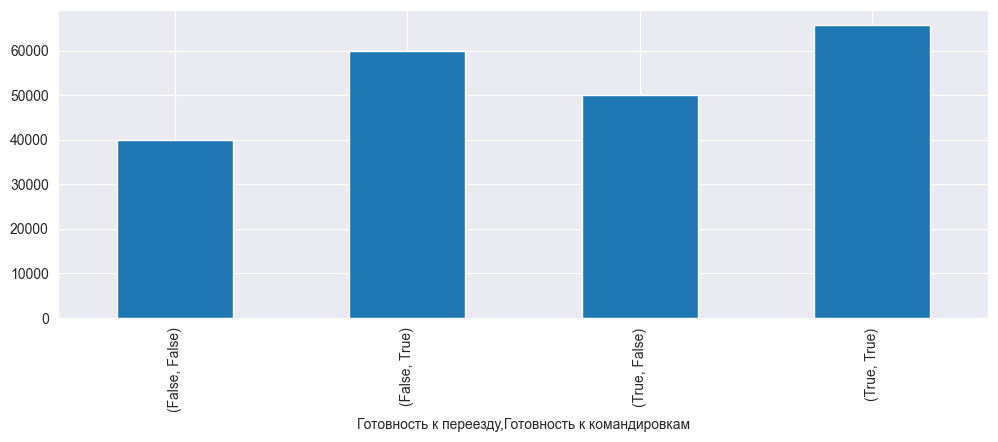

In [281]:
gr_zp = df_c.groupby(['Готовность к переезду', 'Готовность к командировкам'])['ЗП (руб)'].median()
gr_zp.plot( kind='bar', grid=True, figsize=(12, 4), );

медианная ЗП выше у тех, кто готов к переезду и командировкам, причем готовность к командировкам влияет сильнее.

Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**.

In [282]:
gr_zp = df_c[df_c['ЗП (руб)'] < 1000000].groupby(['Возраст', 'Образование'])['ЗП (руб)'].median().reset_index()
pivot_table = gr_zp.pivot(index='Возраст', columns='Образование', values='ЗП (руб)')
fig = px.imshow(
    pivot_table,
    text_auto='.0f',
    aspect='auto',
    title='Тепловая карта: Медианная зарплата по возрасту и образованию',
    labels=dict(x='Образование', y='Возраст', color='Медианная зарплата (руб)')
)
fig.show()

Наиболее низкие медианные ЗП у среднего и среднеспециального образования. При этом возраст соискателей со средним специальным образованием выше чем у соискателей со средним образованием. Наибольшие медианные ЗП выше у соискателей с высшим образованием, при этом возраст соискателей больше.

Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

In [283]:
df_c['опыт (лет)'] = df_c['Опыт работы (месяц)'] / 12
fig = px.scatter(
    df_c,
    x='Возраст',
    y='опыт (лет)',
    title='Зависимость опыта работы (лет) от возраста',
    labels={
        'Возраст': 'Возраст (лет)',
        'Опыт работы (лет)': 'Опыт работы (лет)'
    },
    opacity=0.6,
    color_discrete_sequence=['steelblue']
)
x_line = np.linspace(0, 100, 100)
y_line = x_line
fig.add_scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    name='Прямая y = x',
    line=dict(color='red', width=2, dash='dash')
)
fig.show()



В целом опыт работы меньше возраста соискателей. Однако есть случаи, когда опыт работы чуть меньше возраста, равен ему или превышает.

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


#### Медианная зарплата по уровню образования и полу (до 1 млн руб)

In [284]:
df_y = df_c[df_c['ЗП (руб)'] < 1000000].groupby(['Образование', 'Пол'])['ЗП (руб)'].median().round(0).reset_index()
fig = px.bar(
    df_y,
    x='Образование',
    y='ЗП (руб)',
    color='Пол',
    title='Медианная зарплата по уровню образования и полу (до 1 млн руб)',
    labels={'ЗП (руб)': 'Медианная зарплата (руб)', 'Образование': 'Уровень образования'},
    text='ЗП (руб)',
    barmode='group'
)
fig.update_traces(textposition='outside')
fig.update_layout(
    yaxis_tickformat=',.0f',
    height=500,
    width=800
)

fig.show()

При всех уровнях образования медианная ЗП у мужчин выше чем у женщин

#### Готовность к командировкам и переезду у мужчин и женщин

In [285]:
fig1 = px.histogram(
    df_c,
    x='Пол',
    color='Готовность к командировкам',
    title='Готовность к командировкам по полу',
    barmode='group',
    text_auto=True
)

# Для переезда
fig2 = px.histogram(
    df_c,
    x='Пол',
    color='Готовность к переезду',
    title='Готовность к переезду по полу',
    barmode='group',
    text_auto=True
)

fig1.show()
fig2.show()

Женщины менее мобильны чем мужчины. \
Готовность к командировкам у женщин в соотношении меньше. \
Отношение готовности к переезду примерно одинакова.

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их. 

In [286]:
start_cnt = df_c.shape[0]
mask = df_c.duplicated()
cnt_dub = df_c[mask].shape[0]
df_c.drop_duplicates(inplace=True)
end_cnt = df_c.shape[0]
print(f'начальное: {start_cnt} после очистки: {end_cnt} дублей: {cnt_dub}')

начальное: 44744 после очистки: 44583 дублей: 161


2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах. 

In [287]:
print(df_c.isna().sum())

Ищет работу на должность:            0
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Обновление резюме                    0
Авто                                 0
Образование                          0
Пол                                  0
Возраст                              0
Опыт работы (месяц)                168
Город                                0
Готовность к переезду                0
Готовность к командировкам           0
полная занятость                     0
частичная занятость                  0
проектная работа                     0
стажировка                           0
волонтерство                         0
полный день                          0
сменный график                       0
гибкий график                        0
удаленная работа                     0
вахтовый метод                       0
ЗП (руб)                             0
ЗП (тыс. руб)                        0
опыт (лет)                         168
dtype: int64


3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [288]:
df_c.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность'], inplace=True)
med_e = df_c['Опыт работы (месяц)'].median()
df_c['Опыт работы (месяц)'].fillna(med_e, inplace = True)
print(df_c['Опыт работы (месяц)'].mean().round(0))


114.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_5676\1249947074.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_c['Опыт работы (месяц)'].fillna(med_e, inplace = True)


4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [289]:
index = df_c[(df_c['ЗП (руб)']>1000000) | (df_c['ЗП (руб)'] < 1000)].index
print(f'строк всего:{df_c.shape[0]} строк к удалению: {index.shape[0]}')
df_c.drop(index, inplace=True)
print(f'Осталось: {df_c.shape[0]}')


строк всего:44581 строк к удалению: 89
Осталось: 44492


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [290]:
index = df_c[df_c['Возраст']*12 <= df_c['Опыт работы (месяц)'] ].index
print(f'строк всего:{df_c.shape[0]} строк к удалению: {index.shape[0]}')
df_c.drop(index, inplace=True)
print(f'Осталось: {df_c.shape[0]}')

строк всего:44492 строк к удалению: 7
Осталось: 44485


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

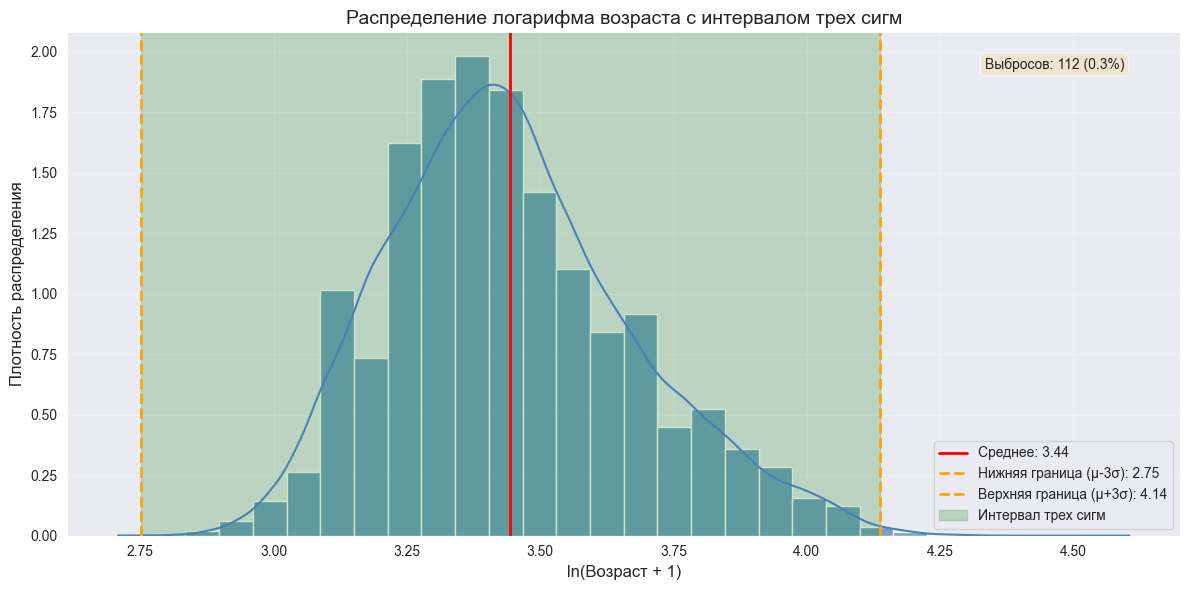

In [291]:
log_age = np.log(df_c['Возраст']) #np.log1p(df_c['Возраст'])

# Расчет статистик для метода трех сигм
mean_log = log_age.mean()
std_log = log_age.std()
# Границы трех сигм
lower_bound = mean_log - 3 * std_log
upper_bound = mean_log + 3 * std_log

# Построение гистограммы
plt.figure(figsize=(12, 6))
sns.histplot(log_age, bins=30, kde=True, stat='density', alpha=0.7, color='steelblue');
plt.axvline(mean_log, color='red', lw=2, linestyle='-', label=f'Среднее: {mean_log:.2f}')
plt.axvline(lower_bound, color='orange', lw=2, linestyle='--', label=f'Нижняя граница (μ-3σ): {lower_bound:.2f}')
plt.axvline(upper_bound, color='orange', lw=2, linestyle='--', label=f'Верхняя граница (μ+3σ): {upper_bound:.2f}')

# Заполнение области между границами
plt.axvspan(lower_bound, upper_bound, alpha=0.2, color='green', label='Интервал трех сигм');
plt.title('Распределение логарифма возраста с интервалом трех сигм', fontsize=14)
plt.xlabel('ln(Возраст + 1)', fontsize=12)
plt.ylabel('Плотность распределения', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

# Добавление аннотации с информацией о выбросах
mask_outliers = (log_age < lower_bound) | (log_age > upper_bound)
outliers = log_age[mask_outliers]
plt.text(0.95, 0.95, f'Выбросов: {len(outliers)} ({len(outliers)/len(log_age)*100:.1f}%)',
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

#### удаляем полученные выбросы

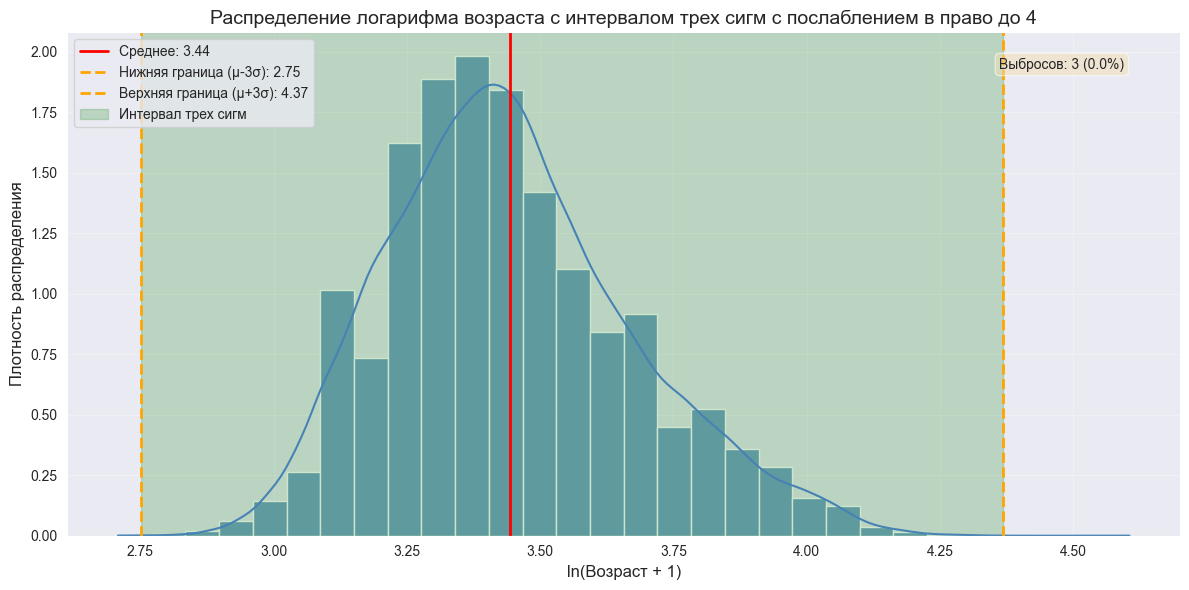

In [292]:
log_age = np.log(df_c['Возраст'])
# Расчет статистик для метода трех сигм
mean_log = log_age.mean()
std_log = log_age.std()
# Границы трех сигм
lower_bound = mean_log - 3 * std_log
upper_bound = mean_log + 4 * std_log

# Построение гистограммы
plt.figure(figsize=(12, 6))
sns.histplot(log_age, bins=30, kde=True, stat='density', alpha=0.7, color='steelblue');
plt.axvline(mean_log, color='red', lw=2, linestyle='-', label=f'Среднее: {mean_log:.2f}')
plt.axvline(lower_bound, color='orange', lw=2, linestyle='--', label=f'Нижняя граница (μ-3σ): {lower_bound:.2f}')
plt.axvline(upper_bound, color='orange', lw=2, linestyle='--', label=f'Верхняя граница (μ+3σ): {upper_bound:.2f}')

# Заполнение области между границами
plt.axvspan(lower_bound, upper_bound, alpha=0.2, color='green', label='Интервал трех сигм');
plt.title('Распределение логарифма возраста с интервалом трех сигм с послаблением в право до 4', fontsize=14)
plt.xlabel('ln(Возраст + 1)', fontsize=12)
plt.ylabel('Плотность распределения', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

# Добавление аннотации с информацией о выбросах
mask_outliers = (log_age < lower_bound) | (log_age > upper_bound)
outliers = log_age[mask_outliers]
plt.text(0.95, 0.95, f'Выбросов: {len(outliers)} ({len(outliers)/len(log_age)*100:.1f}%)',
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

In [293]:
print('Выбросы с ослеблением вправо до 4:')
df_c[mask_outliers]

Выбросы с ослеблением вправо до 4:


,Ищет работу на должность:,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст,Опыт работы (месяц),Город,...,стажировка,волонтерство,полный день,сменный график,гибкий график,удаленная работа,вахтовый метод,ЗП (руб),ЗП (тыс. руб),опыт (лет)
31137,Менеджер по работе с клиентами,"ООО ""ФёрстКэшКомпани""",Менеджер по работе с клиентами,2019-04-06,Не указано,среднее,М,15,2.0,Санкт-Петербург,...,False,False,False,True,True,True,False,10000.0,10,0.166667
32950,Тестировщик игр,OOO ЖМЫХ,Тестировщик ПО,2019-04-09,Не указано,среднее специальное,М,15,3.0,другие,...,False,False,True,False,False,False,False,2000.0,2,0.250000
33654,Frontend-разработчик,Freelance,Frontend-разработчик,2019-04-19,Не указано,среднее специальное,М,100,30.0,Санкт-Петербург,...,True,False,True,False,True,True,False,60000.0,60,2.500000


#### удаление выбросов с ослабленного до 4 вправо датафрейма
***в задании не очень понятно, удалять выбросы с 3 в обе стороны или ослабленные***

In [294]:
print(f'строк до удаления: {df_c.shape[0]}')
idx_to_drop = df_c[mask_outliers].index
df_c.drop(idx_to_drop, inplace=True)
print(f'строк после удаления: {df_c.shape[0]}')

строк до удаления: 44485
строк после удаления: 44482
